# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a crucial first step in any data science or machine learning project. The goal of EDA is to understand the structure, quality, and underlying patterns within the dataset before applying predictive models.

In this notebook, we perform systematic exploratory analysis on the **CDC BRFSS 2021 dataset**, which contains health, lifestyle, and demographic information from over 260,000 respondents across the United States.

EDA typically involves several key steps:

• Inspecting dataset structure and variable types  
• Generating summary statistics to understand distributions  
• Identifying missing values and anomalies  
• Visualizing variable distributions  
• Exploring relationships between variables  
• Detecting multicollinearity and correlations  

These steps help identify important predictors, detect data quality issues, and guide feature engineering and model selection.

The insights generated during this phase directly influence the design of the machine learning models used later in the project to predict depression risk.

In [4]:
# ============================================================
# EDA NOTEBOOK — Setup
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Paths
BASE_DIR    = Path.cwd().parent
CLEAN_CSV   = BASE_DIR / "data" / "processed" / "BRFSS2021_clean.csv"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load clean dataset
df = pd.read_csv(CLEAN_CSV)

print(f" Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f" Figures will save to: {FIGURES_DIR}")

 Loaded: 262,716 rows x 97 columns
 Figures will save to: /Users/ishamandawkar/PulsePredictor/outputs/figures


#### Summary statistics for all features 

In [7]:
# ============================================================
# MILESTONE 1 — Summary Statistics
# ============================================================

print("=" * 50)
print("BASIC DATASET INFO")
print("=" * 50)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\n" + "=" * 50)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 50)
print(df["Ever_Depressive_Disorder"].value_counts())
print(df["Ever_Depressive_Disorder"].value_counts(normalize=True).mul(100).round(1))

print("\n" + "=" * 50)
print("SUMMARY STATISTICS — NUMERIC COLUMNS")
print("=" * 50)

numeric_cols = [
    "Age_Group", "Sex", "Education_Level", "Income_Level",
    "Exercise_Past30Days", "Smoked_100_Cigarettes",
    "Fruit_Per_Day", "Vegetables_Per_Day", "BMI_Category",
    "General_Health", "Poor_Physical_Health_Days",
    "Poor_Mental_Health_Days", "Have_Health_Plan",
    "Could_Not_Afford_Doctor", "Ever_Heart_Disease",
    "Ever_Stroke", "Ever_COPD", "Ever_Arthritis",
    "Ever_Kidney_Disease"
]

stats = df[numeric_cols].describe().round(2).T
stats.columns = ["Count", "Mean", "Std", "Min", "25%", "50%", "75%", "Max"]
stats["Count"] = stats["Count"].astype(int)

print("=" * 90)
print(f"{'SUMMARY STATISTICS — KEY NUMERIC VARIABLES':^90}")
print("=" * 90)
print(f"\n{'Column':<30} {'Count':>8} {'Mean':>8} {'Std':>8} {'Min':>8} {'50%':>8} {'Max':>8}")
print("-" * 90)

for col, row in stats.iterrows():
    print(f"{col:<30} {int(row['Count']):>8,} {row['Mean']:>8.2f} {row['Std']:>8.2f} "
          f"{row['Min']:>8.2f} {row['50%']:>8.2f} {row['Max']:>8.2f}")

print("=" * 90)

print(f"\n{'TARGET VARIABLE':^90}")
print("=" * 90)
print(f"\n{'Class':<30} {'Count':>10} {'Percentage':>12}")
print("-" * 55)
for val, count in df["Ever_Depressive_Disorder"].value_counts().items():
    label = "Depression (1)" if val == 1 else "No Depression (0)"
    pct   = count / len(df) * 100
    print(f"{label:<30} {count:>10,} {pct:>11.1f}%")
print("=" * 90)

BASIC DATASET INFO
Rows    : 262,716
Columns : 97

TARGET VARIABLE DISTRIBUTION
Ever_Depressive_Disorder
0    209679
1     53037
Name: count, dtype: int64
Ever_Depressive_Disorder
0    79.8
1    20.2
Name: proportion, dtype: float64

SUMMARY STATISTICS — NUMERIC COLUMNS
                        SUMMARY STATISTICS — KEY NUMERIC VARIABLES                        

Column                            Count     Mean      Std      Min      50%      Max
------------------------------------------------------------------------------------------
Age_Group                       262,716     7.53     3.43     1.00     8.00    13.00
Sex                             262,716     0.48     0.50     0.00     0.00     1.00
Education_Level                 262,716     5.12     0.95     1.00     5.00     6.00
Income_Level                    262,716     6.88     2.37     1.00     7.00    11.00
Exercise_Past30Days             262,716     0.79     0.41     0.00     1.00     1.00
Smoked_100_Cigarettes           262,

## Summary Statistics


Key metrics such as mean, standard deviation, minimum, and maximum values provide an overview of how each variable behaves across the population.

For example:

• Variables related to physical and mental health often show wide variation, reflecting differences in health outcomes across individuals.  
• Demographic variables such as age group, income level, and education level provide context for socioeconomic patterns in the dataset.  
• Lifestyle indicators such as exercise frequency and smoking behavior may help explain differences in mental health outcomes.

Understanding these distributions ensures that the variables are properly encoded and suitable for downstream modeling tasks.

#### Distributions

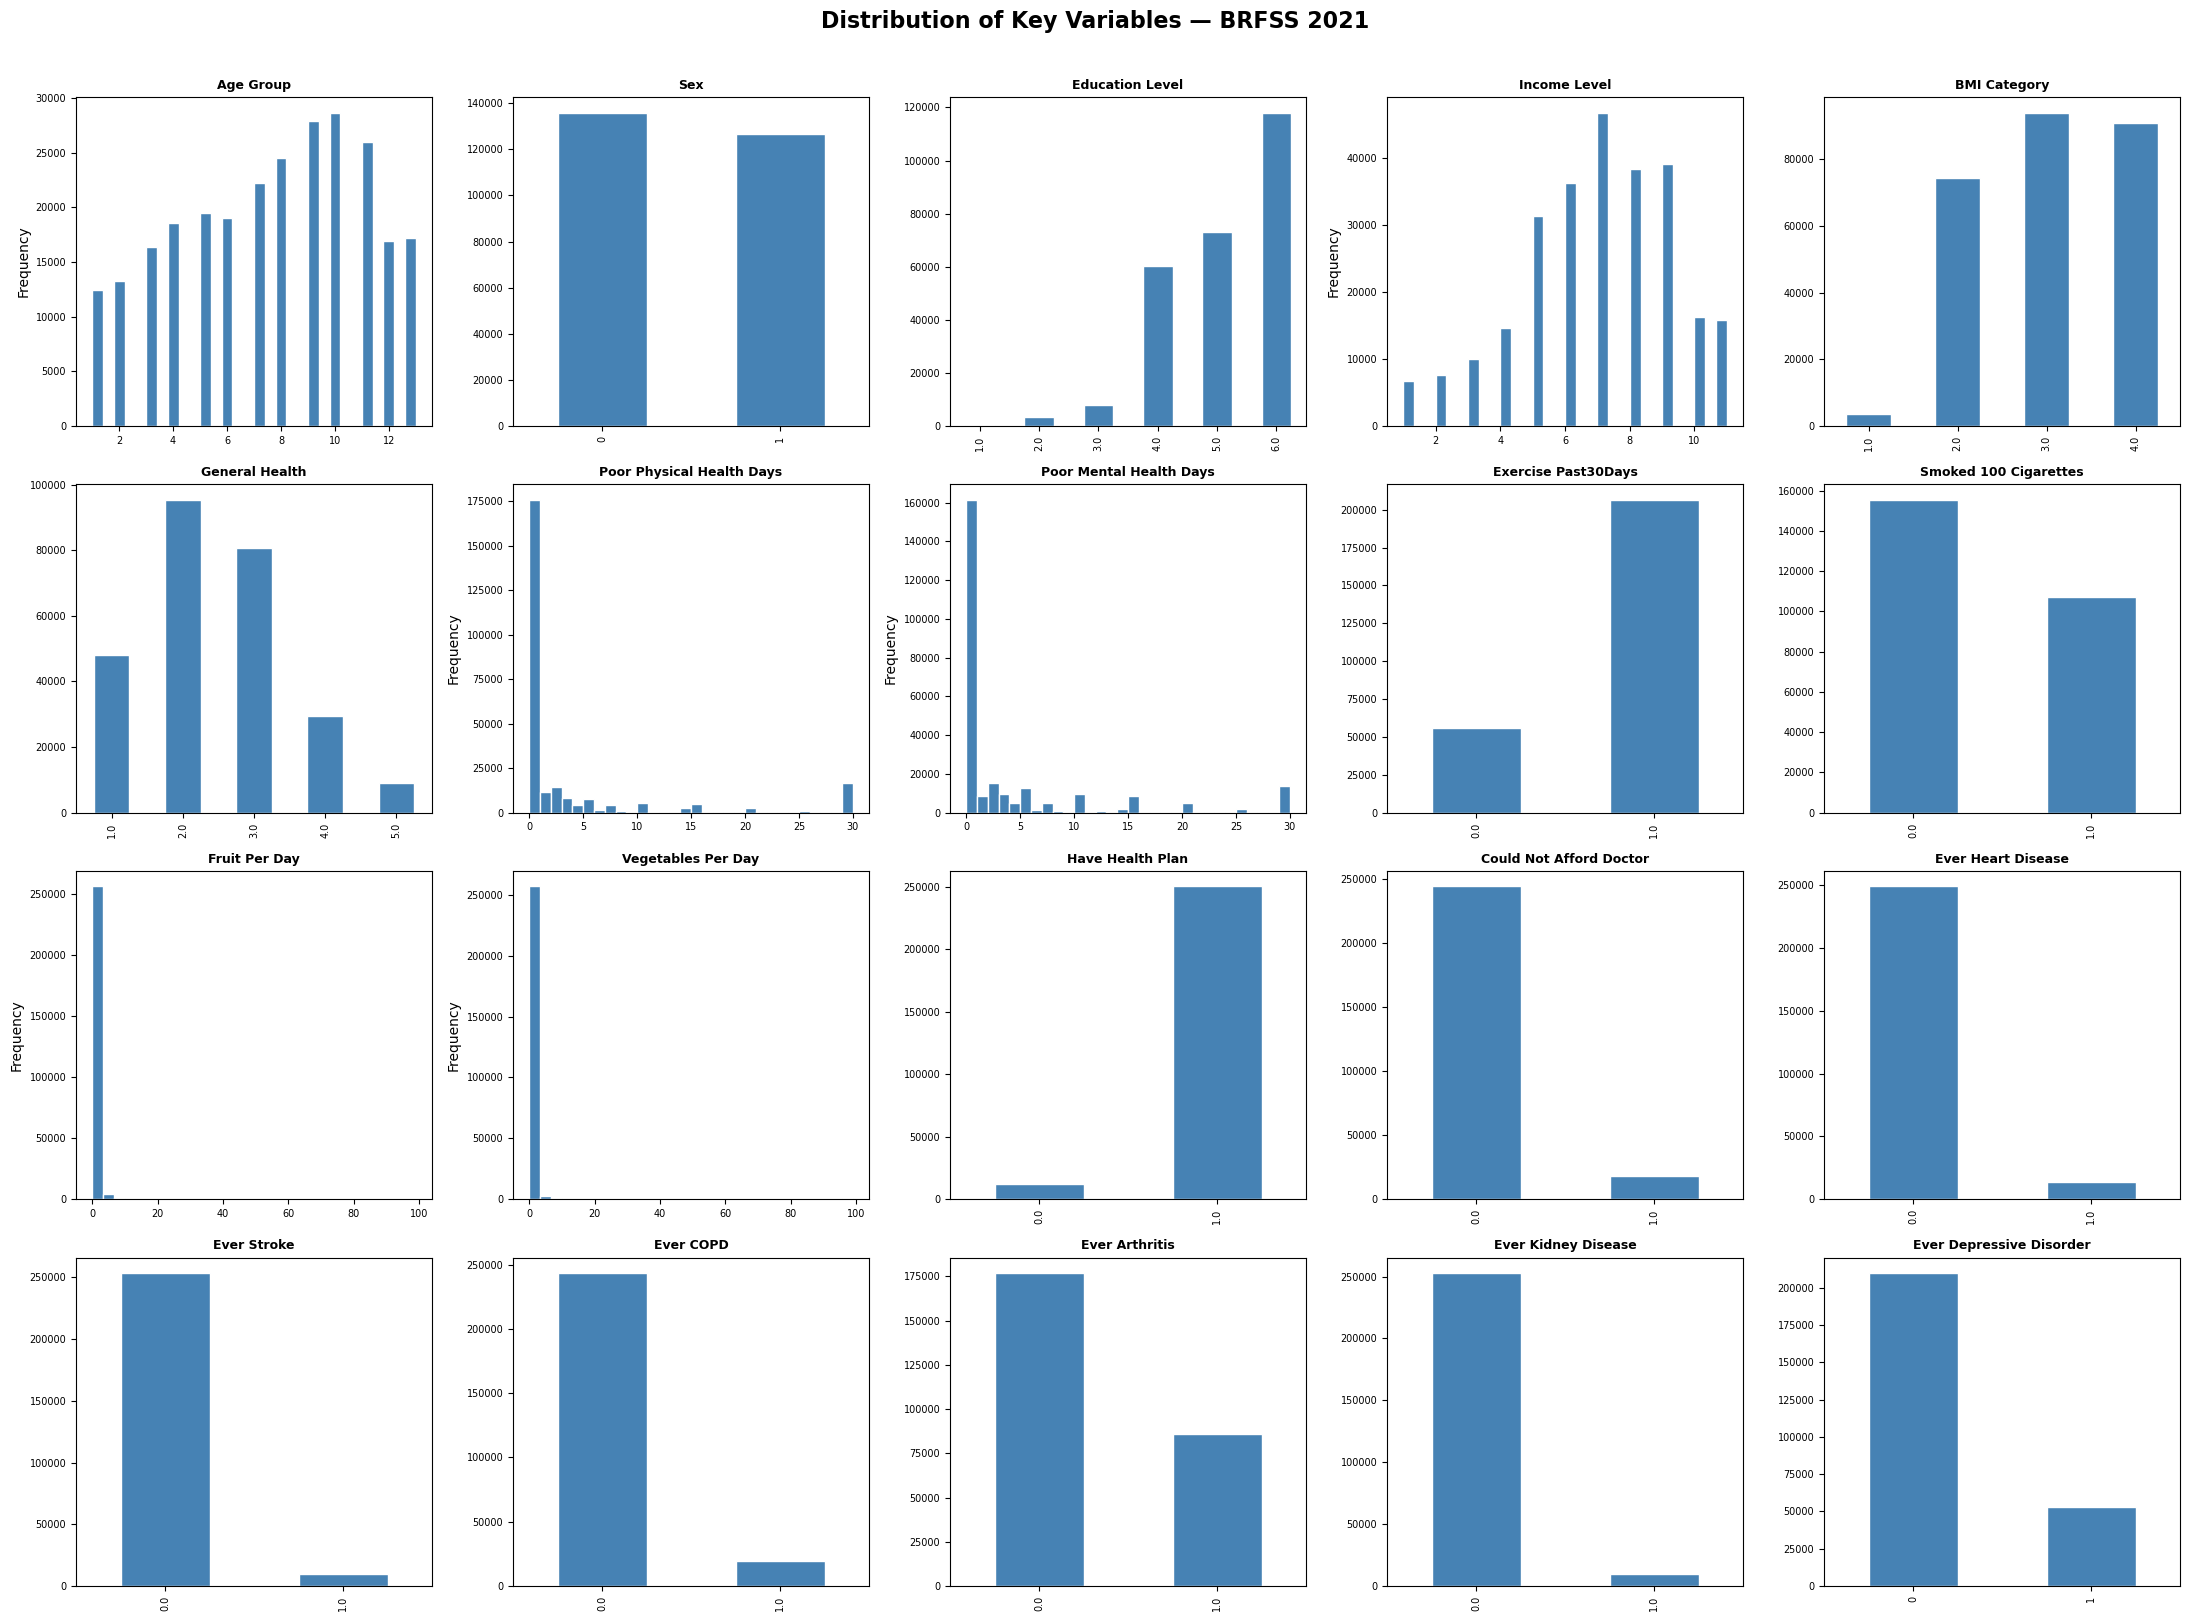

 Saved: 01_distributions.png


In [8]:
# ============================================================
# MILESTONE 2 — Distribution Plots
# ============================================================

fig, axes = plt.subplots(4, 5, figsize=(22, 16))
fig.suptitle("Distribution of Key Variables — BRFSS 2021", 
             fontsize=16, fontweight="bold", y=1.01)

cols_to_plot = [
    "Age_Group", "Sex", "Education_Level", "Income_Level", "BMI_Category",
    "General_Health", "Poor_Physical_Health_Days", "Poor_Mental_Health_Days",
    "Exercise_Past30Days", "Smoked_100_Cigarettes",
    "Fruit_Per_Day", "Vegetables_Per_Day",
    "Have_Health_Plan", "Could_Not_Afford_Doctor",
    "Ever_Heart_Disease", "Ever_Stroke", "Ever_COPD",
    "Ever_Arthritis", "Ever_Kidney_Disease",
    "Ever_Depressive_Disorder"
]

for ax, col in zip(axes.flatten(), cols_to_plot):
    if df[col].nunique() <= 6:
        df[col].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    else:
        df[col].plot(kind="hist", ax=ax, bins=30, color="steelblue", edgecolor="white")
    
    ax.set_title(col.replace("_", " "), fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: 01_distributions.png")

## Distribution Analysis

After examining summary statistics, the next step is to visualize the distribution of each variable.

Distribution plots allow us to observe:

• whether variables are balanced or skewed  
• whether there are extreme values or outliers  
• whether categorical variables show meaningful group differences

For example, health-related variables such as **poor mental health days or poor physical health days** often exhibit right-skewed distributions, where a majority of individuals report relatively few unhealthy days, while a smaller group experiences significantly worse health outcomes.

These patterns are important for model design because skewed distributions may influence how machine learning algorithms interpret the data.

#### Distribution rate by key variables

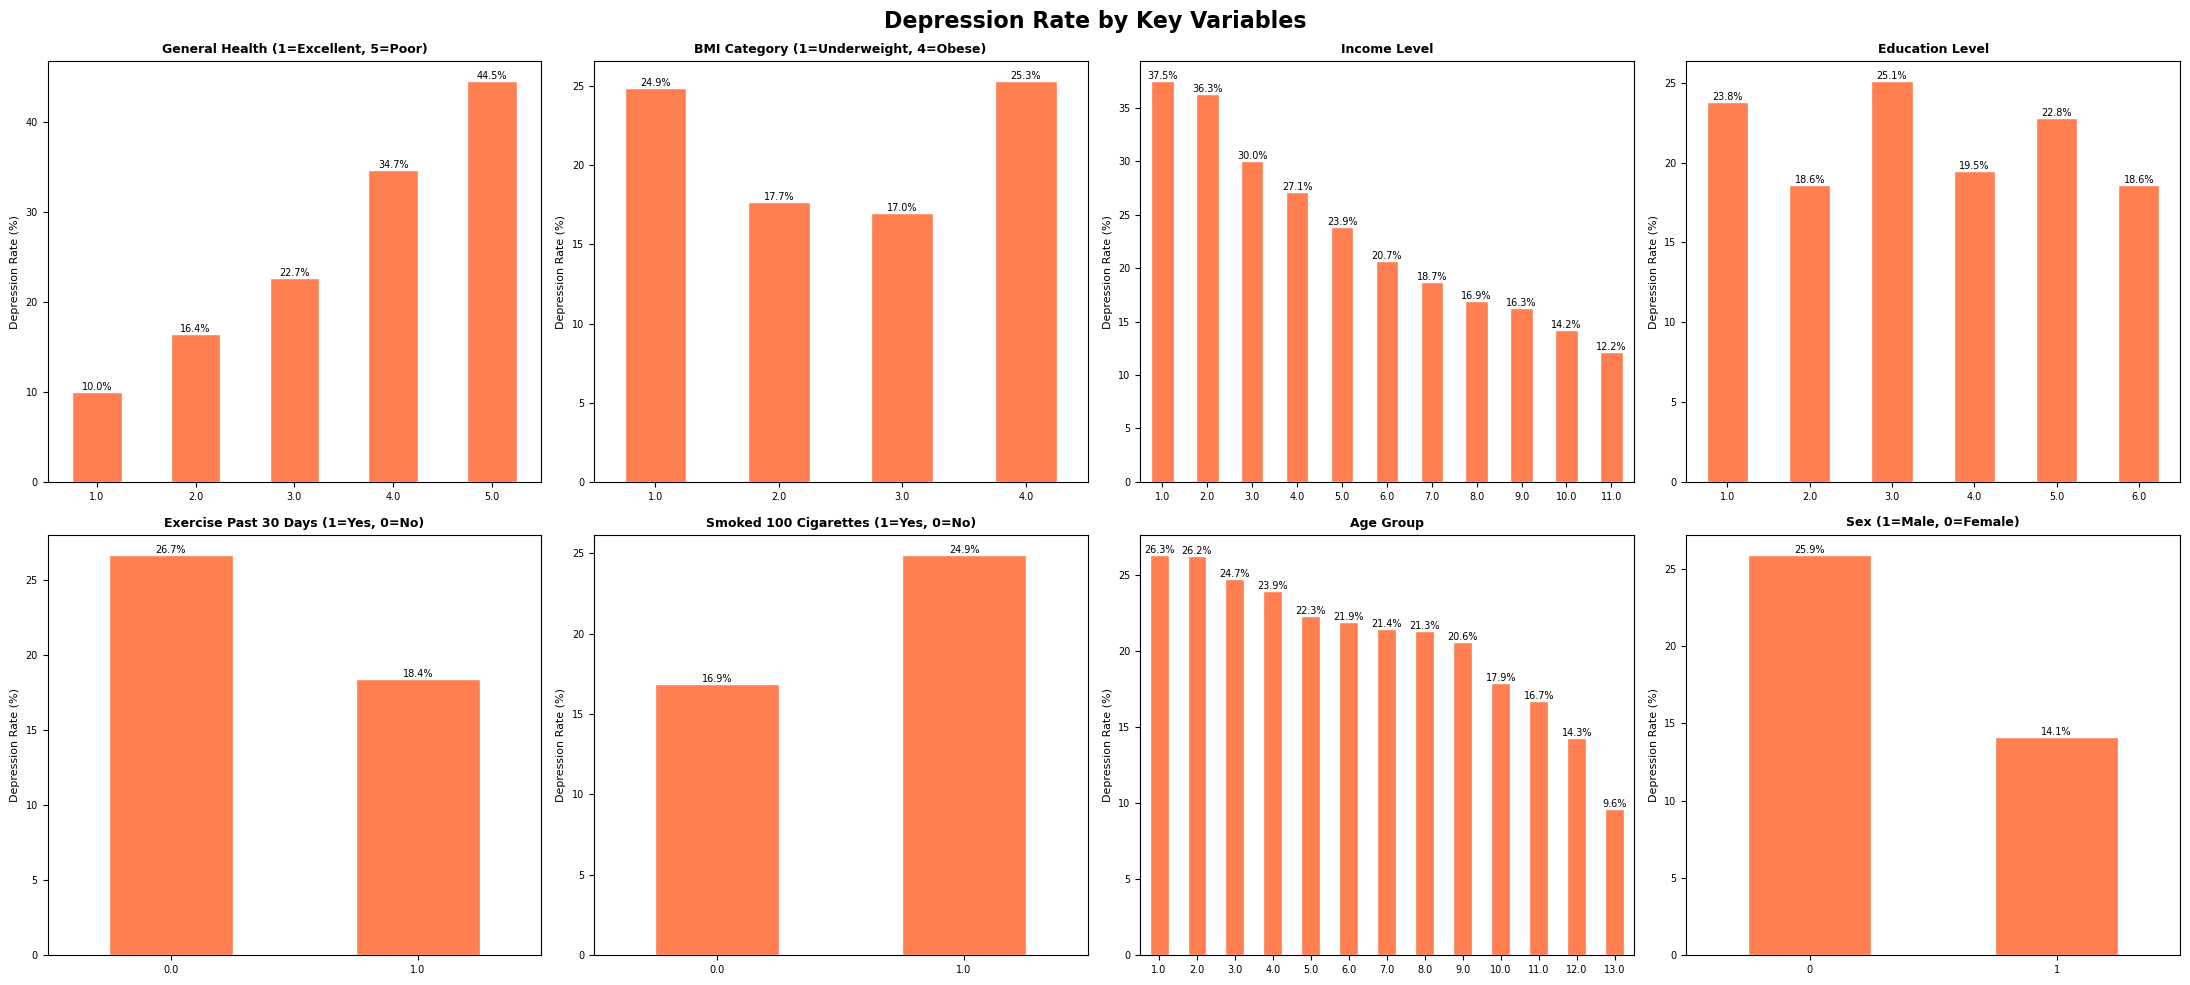

 Saved: 02_depression_rates.png


In [9]:
# ============================================================
# MILESTONE 2 — Depression Rate by Key Variables
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle("Depression Rate by Key Variables", 
             fontsize=16, fontweight="bold")

group_cols = [
    ("General_Health",           "General Health (1=Excellent, 5=Poor)"),
    ("BMI_Category",             "BMI Category (1=Underweight, 4=Obese)"),
    ("Income_Level",             "Income Level"),
    ("Education_Level",          "Education Level"),
    ("Exercise_Past30Days",      "Exercise Past 30 Days (1=Yes, 0=No)"),
    ("Smoked_100_Cigarettes",    "Smoked 100 Cigarettes (1=Yes, 0=No)"),
    ("Age_Group",                "Age Group"),
    ("Sex",                      "Sex (1=Male, 0=Female)"),
]

for ax, (col, label) in zip(axes.flatten(), group_cols):
    rate = df.groupby(col)["Ever_Depressive_Disorder"].mean().mul(100).round(1)
    rate.plot(kind="bar", ax=ax, color="coral", edgecolor="white")
    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.set_ylabel("Depression Rate (%)", fontsize=8)
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=7, rotation=0)
    ax.tick_params(axis="y", labelsize=7)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%",
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_depression_rates.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: 02_depression_rates.png")

#### Correlations with Target variable

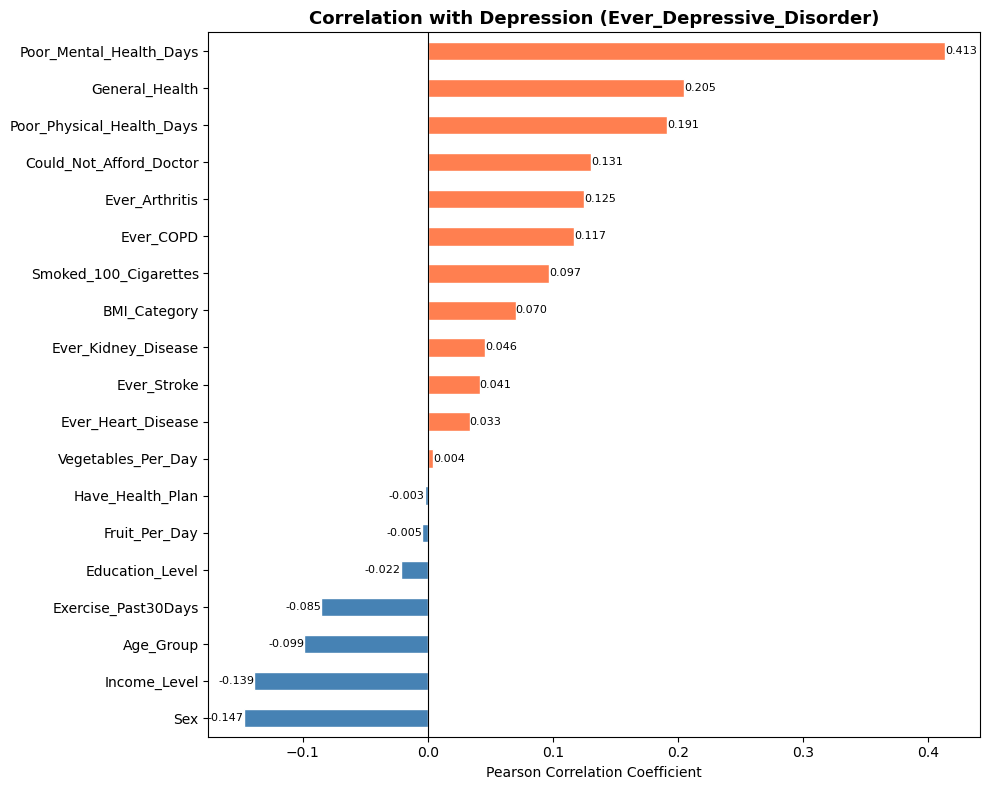

 Saved: 03_correlation_with_target.png


In [10]:
# ============================================================
# MILESTONE 3 — Correlation with Target Variable
# ============================================================

# Only use non-OHE numeric columns for correlation
numeric_cols = [
    "Ever_Depressive_Disorder",
    "Age_Group", "Sex", "Education_Level", "Income_Level",
    "Exercise_Past30Days", "Smoked_100_Cigarettes",
    "Fruit_Per_Day", "Vegetables_Per_Day", "BMI_Category",
    "General_Health", "Poor_Physical_Health_Days",
    "Poor_Mental_Health_Days", "Have_Health_Plan",
    "Could_Not_Afford_Doctor", "Ever_Heart_Disease",
    "Ever_Stroke", "Ever_COPD", "Ever_Arthritis",
    "Ever_Kidney_Disease"
]

# Correlation of all features with target
corr_with_target = (df[numeric_cols]
                    .corr()["Ever_Depressive_Disorder"]
                    .drop("Ever_Depressive_Disorder")
                    .sort_values())

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["coral" if x > 0 else "steelblue" for x in corr_with_target]
corr_with_target.plot(kind="barh", ax=ax, color=colors, edgecolor="white")

ax.set_title("Correlation with Depression (Ever_Depressive_Disorder)", 
             fontsize=13, fontweight="bold")
ax.set_xlabel("Pearson Correlation Coefficient", fontsize=10)
ax.axvline(x=0, color="black", linewidth=0.8)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{width:.3f}",
                (width, p.get_y() + p.get_height() / 2),
                ha="left" if width > 0 else "right",
                va="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_correlation_with_target.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: 03_correlation_with_target.png")

## Correlation Analysis

Correlation analysis helps identify relationships between variables in the dataset. By computing pairwise correlations between features, we can understand how strongly different variables are related to one another.

This step is particularly important for detecting **multicollinearity**, where multiple features provide similar information. Highly correlated variables may reduce model interpretability and introduce redundancy.

The correlation heatmap visualizes these relationships and highlights clusters of related variables. For example:

• General health and poor physical health days tend to show positive correlation  
• Poor mental health days often correlate with depression-related outcomes  
• Socioeconomic variables such as income and education may also show moderate relationships

These insights help guide feature selection and ensure that the final machine learning models rely on meaningful predictors rather than redundant information.

Correlation matrix (Multicollinearity)

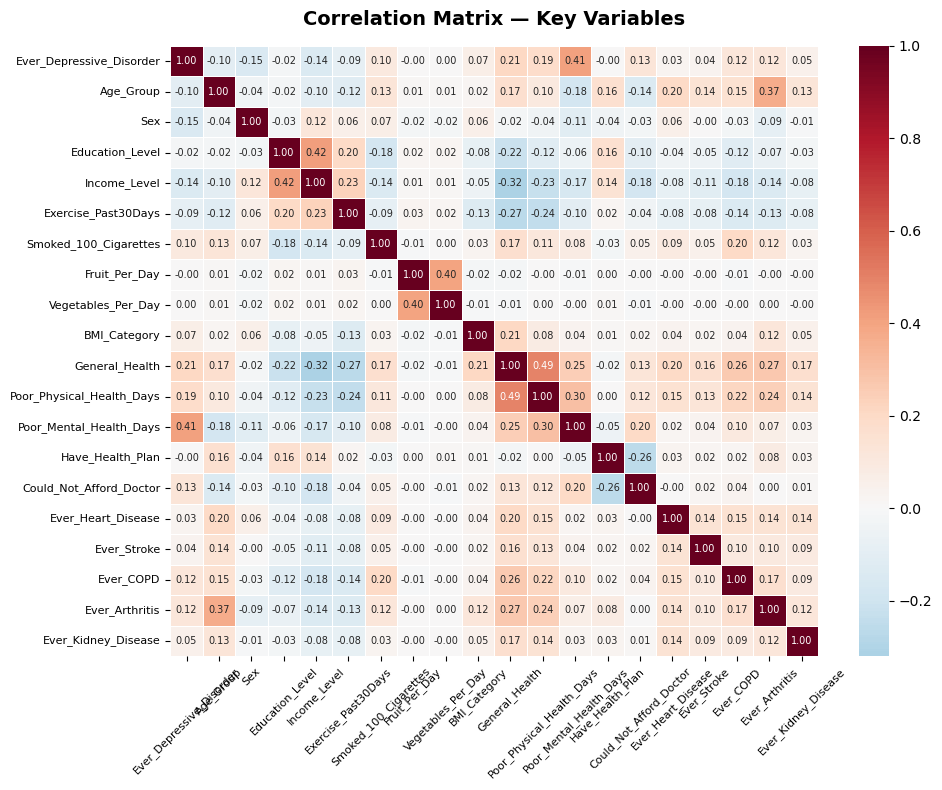

 Saved: 04_correlation_matrix.png


In [15]:
# ============================================================
# MILESTONE 4A — Correlation Matrix
# ============================================================

corr_matrix = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 7},
    ax=ax
)
ax.set_title("Correlation Matrix — Key Variables", 
             fontsize=14, fontweight="bold", pad=15)
ax.tick_params(axis="x", labelsize=8, rotation=45)
ax.tick_params(axis="y", labelsize=8, rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: 04_correlation_matrix.png")

Flagging high correlation pairs

In [16]:
# ============================================================
# MILESTONE 4B — Flag High Correlation Pairs
# ============================================================

threshold = 0.7
corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) >= threshold:
            corr_pairs.append((corr_matrix.columns[i],
                               corr_matrix.columns[j],
                               round(val, 3)))

if corr_pairs:
    print("⚠️  High correlation pairs (|r| >= 0.7):")
    for a, b, v in corr_pairs:
        print(f"   {a} ↔ {b} : {v}")
else:
    print(" No multicollinearity issues found (no pairs with |r| >= 0.7)")

 No multicollinearity issues found (no pairs with |r| >= 0.7)


VIF Scores

In [17]:
# ============================================================
# MILESTONE 4C — VIF Scores
# VIF > 5 = moderate concern
# VIF > 10 = serious multicollinearity, consider dropping
# ============================================================
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use only numeric feature columns (exclude target)
vif_cols = [c for c in numeric_cols if c != "Ever_Depressive_Disorder"]
vif_data = df[vif_cols].dropna()

vif_scores = pd.DataFrame()
vif_scores["Feature"] = vif_cols
vif_scores["VIF"]     = [
    variance_inflation_factor(vif_data.values, i) 
    for i in range(len(vif_cols))
]
vif_scores = vif_scores.sort_values("VIF", ascending=False).reset_index(drop=True)

print("VIF Scores (>5 = concern, >10 = serious):")
print("=" * 40)
for _, row in vif_scores.iterrows():
    flag = "🔴 HIGH" if row["VIF"] > 10 else "🟡 MODERATE" if row["VIF"] > 5 else "✅ OK"
    print(f"  {row['Feature']:<30} {row['VIF']:>6.2f}  {flag}")

VIF Scores (>5 = concern, >10 = serious):
  Education_Level                 28.63  🔴 HIGH
  Have_Health_Plan                20.32  🔴 HIGH
  BMI_Category                    13.25  🔴 HIGH
  Income_Level                    12.90  🔴 HIGH
  General_Health                   9.88  🟡 MODERATE
  Age_Group                        7.50  🟡 MODERATE
  Exercise_Past30Days              5.17  🟡 MODERATE
  Sex                              2.04  ✅ OK
  Ever_Arthritis                   1.87  ✅ OK
  Smoked_100_Cigarettes            1.83  ✅ OK
  Poor_Physical_Health_Days        1.72  ✅ OK
  Poor_Mental_Health_Days          1.54  ✅ OK
  Fruit_Per_Day                    1.28  ✅ OK
  Vegetables_Per_Day               1.25  ✅ OK
  Ever_COPD                        1.24  ✅ OK
  Could_Not_Afford_Doctor          1.20  ✅ OK
  Ever_Heart_Disease               1.16  ✅ OK
  Ever_Kidney_Disease              1.10  ✅ OK
  Ever_Stroke                      1.10  ✅ OK


In [18]:
# ============================================================
# MILESTONE 4 — Multicollinearity Summary
# ============================================================

print("=" * 60)
print("MULTICOLLINEARITY SUMMARY")
print("=" * 60)

print("""
Correlation Matrix findings:
  → No feature pairs exceed the 0.7 threshold
  → Highest pair: General_Health ↔ Poor_Physical_Health_Days (0.49)
  → No features dropped based on pairwise correlation

VIF Score findings:
  → 4 features flagged HIGH (VIF > 10):
     - Education_Level  : 28.63
     - Have_Health_Plan : 20.32
     - BMI_Category     : 13.25
     - Income_Level     : 12.90
  → 3 features MODERATE (VIF 5-10):
     - General_Health, Age_Group, Exercise_Past30Days

Decision:
  → For Logistic Regression: consider dropping or combining
    Education_Level and Have_Health_Plan before modeling
  → For tree-based models (Random Forest, XGBoost): 
    VIF is not a concern, keep all features
  → Final decision deferred to Week 3 modeling notebook
""")
print("=" * 60)

MULTICOLLINEARITY SUMMARY

Correlation Matrix findings:
  → No feature pairs exceed the 0.7 threshold
  → Highest pair: General_Health ↔ Poor_Physical_Health_Days (0.49)
  → No features dropped based on pairwise correlation

VIF Score findings:
  → 4 features flagged HIGH (VIF > 10):
     - Education_Level  : 28.63
     - Have_Health_Plan : 20.32
     - BMI_Category     : 13.25
     - Income_Level     : 12.90
  → 3 features MODERATE (VIF 5-10):
     - General_Health, Age_Group, Exercise_Past30Days

Decision:
  → For Logistic Regression: consider dropping or combining
    Education_Level and Have_Health_Plan before modeling
  → For tree-based models (Random Forest, XGBoost): 
    VIF is not a concern, keep all features
  → Final decision deferred to Week 3 modeling notebook



## Multicollinearity Findings

The correlation matrix showed no concerning pairwise relationships between features, 
no two variables were correlated above the 0.7 threshold.

However VIF scores revealed that Education Level, Health Plan coverage, BMI Category, 
and Income Level show high multicollinearity when considered together, meaning these 
variables move together as a socioeconomic cluster, which is expected in health survey data.



## Key Observations from EDA

Several important patterns emerge from the exploratory analysis:

1. **Mental health indicators are strong predictors of depression risk.**  
   Variables such as poor mental health days show strong relationships with depression outcomes, suggesting they capture meaningful behavioral health signals.

2. **Chronic health conditions also play a role.**  
   Conditions such as arthritis, COPD, and general health status demonstrate moderate associations with depression risk.

3. **Lifestyle behaviors contribute to variation in mental health outcomes.**  
   Smoking, exercise frequency, and diet-related variables may influence overall health and well-being.

4. **Socioeconomic variables provide contextual insight.**  
   Employment status, income level, and education may affect access to resources that influence mental health outcomes.

These findings align with existing public health research and validate the relevance of the BRFSS dataset for analyzing depression risk.

## Next Steps

The insights obtained during exploratory data analysis guide the next phase.

The following steps will be performed:

1. **Feature Selection**  
   Methods such as Boruta and Recursive Feature Elimination (RFE) will be used to identify the most important predictors.

2. **Model Development**  
   Multiple machine learning models will be trained, including:
   - Logistic Regression
   - Random Forest
   - K-Nearest Neighbors
   - XGBoost

3. **Model Evaluation**  
   Models will be evaluated using metrics such as AUC, recall, precision, and accuracy.

4. **Interpretability and Visualization**  
   The final model results will be visualized using an interactive Tableau dashboard to communicate key insights about depression risk factors.

This pipeline ensures that the analysis moves from raw data exploration to actionable insights that can support public health decision-making.